In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import re

# Set plot style
sns.set_theme(style="whitegrid")

# Load Data

We will load the participant data files from the `BRSM data csv/` directory.
Each file represents a participant's session.
We extract the condition (AB/NB) from the filename and the participant ID.
We also load `target_and_lures.csv` to map targets and lures.

In [2]:
# Path to data directory
data_dir = 'BRSM data csv'

# List all CSV files in the directory
files = glob.glob(os.path.join(data_dir, '*.csv'))

all_data = []

for file in files:
    try:
        # Read the CSV file
        df = pd.read_csv(file)
        
        # Extract participant ID and Condition from filename
        filename = os.path.basename(file)
        # Filename pattern: sub100_AB_recognitionstage_...
        match = re.search(r'(sub\d+)_([A-Z]+)_', filename, re.IGNORECASE)
        if match:
            participant_id = match.group(1)
            condition = match.group(2).upper()  # Ensure 'AB' or 'NB'
        else:
            # Fallback or skip if pattern doesn't match
            print(f"Skipping file with unexpected name format: {filename}")
            continue
            
        # Add extracted info to DataFrame
        df['participant_id'] = participant_id
        df['condition'] = condition
        
        # Append to list
        all_data.append(df)
        
    except Exception as e:
        print(f"Error reading {file}: {e}")

# Concatenate all DataFrames
if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    print(f"Loaded {len(all_data)} files into a single DataFrame with {len(combined_df)} rows.")
else:
    print("No data loaded.")

Skipping file with unexpected name format: sub133_AB _recognitionstage_2026-02-02_13h23.31.011.csv
Loaded 170 files into a single DataFrame with 7607 rows.


# Preprocess Data

Filter for valid recognition trials. We expect rows where `recogloop.resp.keys` is populated (or `recogloop.resp.corr`).
We also extract the Target Type (BB/EM) from the `target_img` filename.

In [3]:
# Filter for rows that are part of the recognition loop and have a response
# The column 'recogloop.resp.keys' should be present and not null for valid trials
if 'recogloop.resp.keys' in combined_df.columns:
    recog_data = combined_df.dropna(subset=['recogloop.resp.keys']).copy()
else:
    print("Warning: 'recogloop.resp.keys' column not found!")
    recog_data = combined_df.copy()

# Extract Target Type (BB/EM) from 'target_img' column
# Example: frames\Vid1_EM_T.png -> EM
def extract_target_type(path):
    if pd.isna(path):
        return None
    match = re.search(r'_([A-Z]{2})_', str(path))
    if match:
        return match.group(1)
    return None

recog_data['target_type'] = recog_data['target_img'].apply(extract_target_type)

# Check unique target types extracted
print("Extracted Target Types:", recog_data['target_type'].unique())

Extracted Target Types: <ArrowStringArray>
['EM', 'BB']
Length: 2, dtype: str


# Visualize Accuracy

We calculate the mean accuracy (`recogloop.resp.corr`) grouped by Condition (AB/NB) and Target Type (BB/EM).

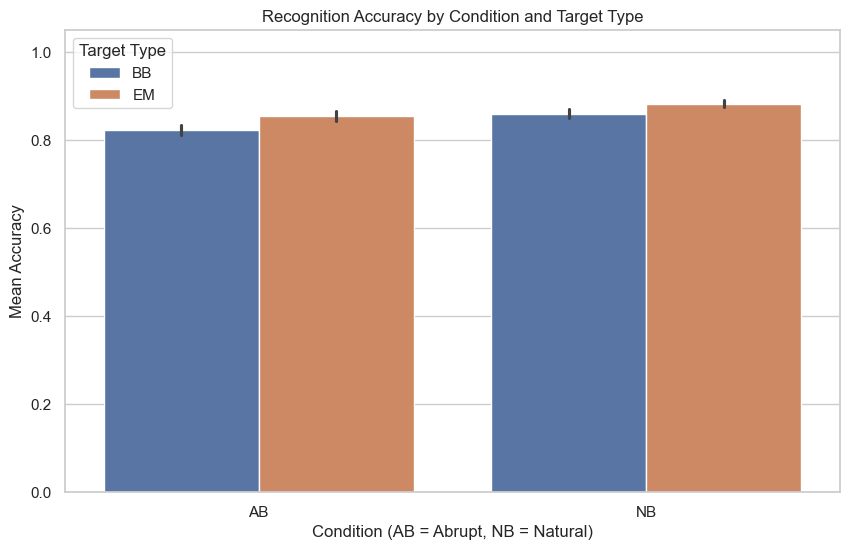

In [4]:
# Calculate mean accuracy per participant first, then average across participants
# Group by participant, condition, target_type
accuracy_per_participant = recog_data.groupby(['participant_id', 'condition', 'target_type'])['recogloop.resp.corr'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=accuracy_per_participant, x='condition', y='recogloop.resp.corr', hue='target_type', errorbar='se')
plt.title('Recognition Accuracy by Condition and Target Type')
plt.ylabel('Mean Accuracy')
plt.xlabel('Condition (AB = Abrupt, NB = Natural)')
plt.ylim(0, 1.05)
plt.legend(title='Target Type')
plt.show()

# Visualize Confidence

We calculate the mean confidence rating (`recogloop.conf_radio.response`) grouped by Condition and Target Type.

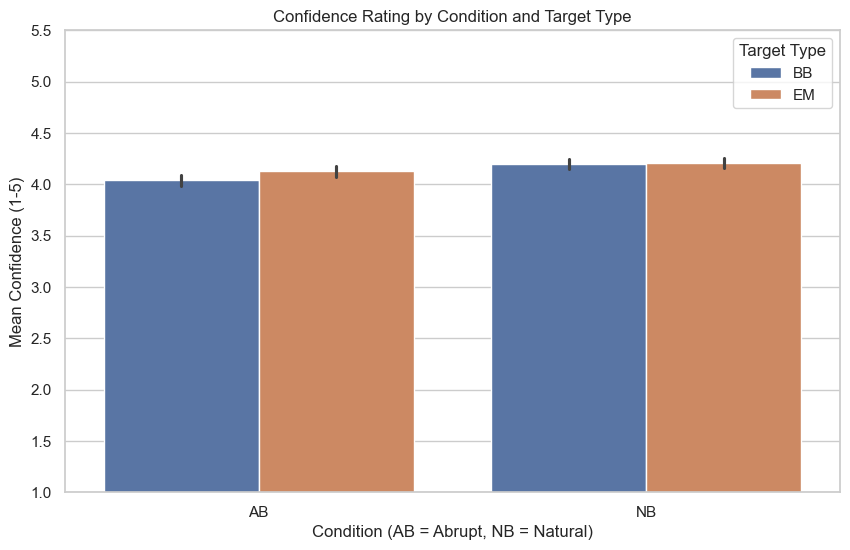

In [5]:
# Calculate mean confidence per participant
if 'recogloop.conf_radio.response' in recog_data.columns:
    confidence_per_participant = recog_data.groupby(['participant_id', 'condition', 'target_type'])['recogloop.conf_radio.response'].mean().reset_index()

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(data=confidence_per_participant, x='condition', y='recogloop.conf_radio.response', hue='target_type', errorbar='se')
    plt.title('Confidence Rating by Condition and Target Type')
    plt.ylabel('Mean Confidence (1-5)')
    plt.xlabel('Condition (AB = Abrupt, NB = Natural)')
    plt.ylim(1, 5.5)
    plt.legend(title='Target Type')
    plt.show()
else:
    print("Confidence column 'recogloop.conf_radio.response' not found.")

# Summary and Notes
- **Accuracy**: We visualized the recognition accuracy across the two conditions (Abrupt vs Natural) and two target types (Before Boundary vs Event Middle).
- **Confidence**: We examined the mean confidence ratings for the same groups.
- **Difficulty Levels**: The dataset provided does not contain explicit difficulty level labels for the lure images, so this factor was not included in the visualization.
